1. **Modelo del Cúmulo**
   $$\Phi_c(\mu_{\alpha*}, \mu_\delta) = \frac{1}{2\pi\sigma_c^2} \exp\left( -\frac{1}{2} \left[ \frac{(\mu_{\alpha*} - \mu_{xc})^2 + (\mu_\delta - \mu_{yc})^2}{\sigma_c^2} \right] \right)$$

2. **Distancia de Mahalanobis para el campo**
   $$z_f = \frac{(\mu_{\alpha*} - \mu_{xf})^2}{\sigma_{fx}^2} - 2\rho\frac{(\mu_{\alpha*} - \mu_{xf})(\mu_\delta - \mu_{yf})}{\sigma_{fx}\sigma_{fy}} + \frac{(\mu_\delta - \mu_{yf})^2}{\sigma_{fy}^2}$$

3. **Modelo del Campo Estelar**
   $$\Phi_f(\mu_{\alpha*}, \mu_\delta) = \frac{1}{2\pi\sigma_{fx}\sigma_{fy}\sqrt{1-\rho^2}} \exp\left( -\frac{1}{2(1-\rho^2)} z_f \right)$$

4. **Función de Costo (Log-Likelihood Negativo)**
   $$\mathcal{L}(\theta) = -\sum_{i=1}^{N} \ln \left[ n_c \cdot \Phi_c(\mu_{\alpha*, i}, \mu_{\delta, i}) + (1 - n_c) \cdot \Phi_f(\mu_{\alpha*, i}, \mu_{\delta, i}) \right]$$

5. **Probabilidad Posterior (Teorema de Bayes)**
   $$P(\text{Cúmulo} \mid \mu_{\alpha*}, \mu_\delta) = \frac{n_c \Phi_c}{n_c \Phi_c + (1 - n_c) \Phi_f}$$

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm

In [29]:
def obtener_datos_gaia(file_path):
    """ Descarga datos de Gaia DR3 sin filtros de calidad adicionales. """
    
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    
    # Centro de M41 y radio de 1 grado
    ra_c, dec_c, radius = 101.525, -20.733, 1.0
    
    # Consulta ADQL limpia (Sin RUWE ni flux_errors)
    query = f"""
    SELECT 
        source_id, ra, dec, parallax, pmra, pmdec,
        ra_error, dec_error, parallax_error, pmra_error, pmdec_error,
        phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra_c}, {dec_c}, {radius})) = 1
    """
    
    
    job = Gaia.launch_job_async(query)
    data = job.get_results().to_pandas()
    data.to_csv(file_path, index=False)
    return data

En el cálculo de la Función de Costo (Log-Likelihood Negativo), se evalua el logaritmo natural de la probabilidad combinada L. Matemáticamente, el dominio de la función logarítmica es $(0,\infty)$. Si una estrella se encuentra físicamente muy alejada de los centros, tanto del campo como del cúmulo, su probabilidad combinada puede aproximarse a cero asintóticamente:

$$\lim_{L \to 0^+} \ln(L) = -\infty$$

La función ```np.maximum(L, 1e-15) ``` compara cada valor del array L con el número $10^{-15}$ y elige el mayor. En el caso de que $L=0$ se reemplaza por $10^{-15}$:

$$\mathcal{L}(\theta) = -\sum_{i=1}^{N} \ln(\max[L_i, \epsilon])$$

$$\text{donde } \epsilon = 10^{-15}$$

Se utiliza $10^{-15}$ ya que es el mayor límite de floats en 64-bits. En otras palabras, es el máximo antes que el logaritmo se vaya a infinito.

In [30]:
def neg_log_likelihood(theta, pmra, pmdec):
    """ Función de Verosimilitud bivariada. """
    nc, mu_xc, mu_yc, sig_c, mu_xf, mu_yf, sig_fx, sig_fy, rho = theta
    
    # Restricciones físicas de los parámetros
    if nc <= 0 or nc >= 1 or sig_c <= 0 or sig_fx <= 0 or sig_fy <= 0 or rho <= -1 or rho >= 1:
        return np.inf

    # Modelo del Cúmulo (Circular)
    z_c = ((pmra - mu_xc)**2 + (pmdec - mu_yc)**2) / (sig_c**2)
    pdf_c = (1.0 / (2 * np.pi * sig_c**2)) * np.exp(-0.5 * z_c)

    # Modelo del Campo (Elíptico con Correlación)
    z_f = (((pmra - mu_xf)**2 / sig_fx**2) 
           - 2 * rho * (pmra - mu_xf) * (pmdec - mu_yf) / (sig_fx * sig_fy) 
           + ((pmdec - mu_yf)**2 / sig_fy**2))
    factor_f = 1.0 / (2 * np.pi * sig_fx * sig_fy * np.sqrt(1 - rho**2))
    pdf_f = factor_f * np.exp(-0.5 * z_f / (1 - rho**2))

    L = nc * pdf_c + (1 - nc) * pdf_f
    L = np.maximum(L, 1e-15) # Estabilidad numérica
    
    return -np.sum(np.log(L))

Procesando M41:   0%|          | 0/7 [00:00<?, ?paso/s]

Paso 4: Optimizando modelo:  43%|████▎     | 3/7 [00:00<00:02,  1.89paso/s]  


[DATA] Estrellas descargadas: 134065
[DATA] Estrellas procesadas (con paralaje > 1): 16934


Paso 7: Exportando miembros: 100%|██████████| 7/7 [00:02<00:00,  3.46paso/s] 



[RESULTADO] Se aislaron 1112 estrellas miembro (P > 50.0%).
[RESULTADO] Catálogo exportado exitosamente a: C:\Users\santi\Downloads\M41_Miembros_Confirmados.csv


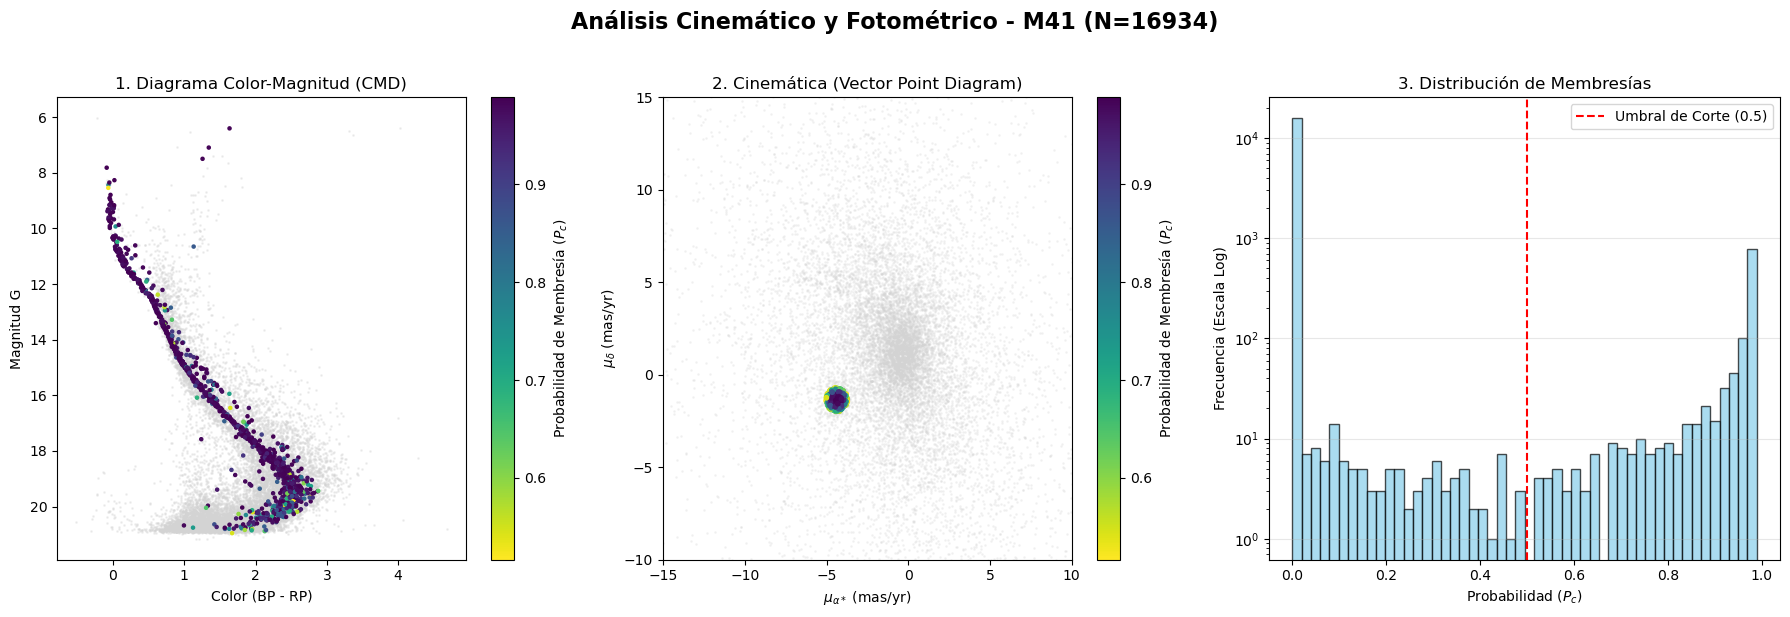

In [31]:


def main():
    """
    Script principal para el análisis cinemático y fotométrico del cúmulo M41.
    Utiliza datos de la misión espacial Gaia DR3 para estimar la probabilidad 
    de membresía de las estrellas mediante un Modelo de Mezcla Gaussiana (GMM) 
    en 2D, ajustando los movimientos propios (pmra, pmdec).
    """
    
    # --- CONFIGURACIÓN GENERAL ---
    umbral_membresia = 0.5  
    
    steps = ["Descarga", "Limpieza Mínima", "Priors", "Optimización", "Probabilidades", "Gráficas", "Exportación"]
    # Barra de carga
    pbar = tqdm(total=len(steps), desc="Procesando M41", unit="paso")

    # --- PASO 1: EXTRACCIÓN DE DATOS ---
    pbar.set_description("Paso 1: Descargando datos") 
    raw_file_path = r"C:\Users\santi\Downloads\M41_GaiaDR3_Raw_Data_NoFilter.csv"
    data = obtener_datos_gaia(raw_file_path) 
    pbar.update(1)

    # --- PASO 2: LIMPIEZA MÍNIMA ---
    pbar.set_description("Paso 2: Limpieza mínima") 
    total_descargado = len(data)
    
    # 1. Eliminación de NaNs 
    # Se eliminan las filas con valores nulos (NaN) en columnas críticas.
    # Esto evita errores en los cálculos vectorizados y en el optimizador.
    data = data.dropna(
        subset=[
            'pmra',               # Movimiento propio en Ascensión Recta
            'pmdec',              # Movimiento propio en Declinación
            'parallax',           # Paralaje (necesario para estimar distancia)
            'phot_g_mean_mag',    # Magnitud G (brillo total)
            'phot_bp_mean_mag',   # Magnitud BP (banda azul)
            'phot_rp_mean_mag'    # Magnitud RP (banda roja)
        ]
    )    
    # 2. Filtro para conservar solo estrellas con paralaje > 1 mas (Distancia < 1000 pc)
    data = data[data['parallax'] > 1]
    
    total_final = len(data)
    
    # Actualización de la barra de carga en consola
    tqdm.write(f"\n[DATA] Estrellas descargadas: {total_descargado}")
    tqdm.write(f"[DATA] Estrellas procesadas (con paralaje > 1): {total_final}")
    
    # Extracción de arrays subyacentes de NumPy.
    # Esto evita la sobrecarga de Pandas y acelera drásticamente 
    # los cálculos matemáticos vectorizados posteriores.
    pmra = data['pmra'].values
    pmdec = data['pmdec'].values
    pbar.update(1)

    # --- PASO 3: ESTIMACIÓN DE CONDICIONES INICIALES (PRIORS) ---
    pbar.set_description("Paso 3: Estimación de priors")
    
    H, xedges, yedges = np.histogram2d(pmra, pmdec, bins=100, range=[[-15, 5], [-5, 15]])
    
    # argmax -> Posición del valor más alto en la matriz plana.
    # np.unravel_index -> Convierte esa posición plana a formato (fila, columna).
    x_idx, y_idx = np.unravel_index(np.argmax(H), H.shape)
    
    # Punto medio de los bins del histograma.
    # Esto se utiliza para calcular la coordenada geométrica exacta 
    # del centro inicial del cúmulo antes de iniciar la optimización.
    mu_xc_init = (xedges[x_idx] + xedges[x_idx+1]) / 2
    mu_yc_init = (yedges[y_idx] + yedges[y_idx+1]) / 2

    # Definición de parámetros iniciales (Priors)
    theta0 = [
        0.05,               # nc: Proporción inicial de miembros (5%)
        mu_xc_init,         # mu_xc: Centro inicial en RA
        mu_yc_init,         # mu_yc: Centro inicial en Dec
        0.5,                # sig_c: Dispersión del cúmulo (compacto)
        np.median(pmra),    # mu_xf: Centro del campo en RA
        np.median(pmdec),   # mu_yf: Centro del campo en Dec
        np.std(pmra),       # sig_fx: Dispersión del campo en RA
        np.std(pmdec),      # sig_fy: Dispersión del campo en Dec
        0.0                 # rho: Correlación inicial
    ]

    # Límites de búsqueda para el optimizador
    bounds = [
        (0.001, 0.5),   # nc
        (-20, 20),      # mu_xc
        (-20, 20),      # mu_yc
        (0.01, 3.0),    # sig_c
        (-30, 30),      # mu_xf
        (-30, 30),      # mu_yf
        (1.0, 30.0),    # sig_fx
        (1.0, 30.0),    # sig_fy
        (-0.99, 0.99)   # rho
    ]
    pbar.update(1)

    # --- PASO 4: OPTIMIZACIÓN DEL MODELO ---
    pbar.set_description("Paso 4: Optimizando modelo")
    
    # Ejecutamos el optimizador para encontrar los mejores parámetros
    result = minimize(
        neg_log_likelihood,    # La función de error a minimizar
        theta0,                # Nuestras conjeturas iniciales (Priors)
        args=(pmra, pmdec),    # Los datos reales de las estrellas
        method='L-BFGS-B',     # Algoritmo eficiente para muchos parámetros
        bounds=bounds          # Los límites físicos que definimos
    )
    
    # Extraemos los parámetros finales optimizados
    theta_opt = result.x 
    pbar.update(1)

    # --- PASO 5: CÁLCULO DE PROBABILIDAD DE MEMBRESÍA (TEOREMA DE BAYES) ---
    pbar.set_description("Paso 5: Calculando membresía")
    
    # Desempaquetamos los parámetros que encontró el optimizador
    nc, mu_xc, mu_yc, sig_c, mu_xf, mu_yf, sig_fx, sig_fy, rho = theta_opt
    
    # -- Distribución del Cúmulo (Gaussiana circular 2D) --
    z_c = (
        ((pmra - mu_xc)**2 + (pmdec - mu_yc)**2) 
        / (sig_c**2)
    )
    
    # pdf_c: Función de Densidad de Probabilidad.
    # Evalúa qué tan probable es observar esta cinemática 
    # asumiendo que la estrella SÍ pertenece al cúmulo.
    pdf_c = ((1.0 / (2 * np.pi * sig_c**2)) * np.exp(-0.5 * z_c))
    
    # -- Distribución del Campo (Gaussiana elíptica 2D con correlación) --
    # z_f: Distancia al centro del campo. 
    # Incluye el parámetro 'rho' por si el ruido de fondo 
    # tiene un flujo de movimiento preferencial o inclinado.
    z_f = (
        ((pmra - mu_xf)**2 / sig_fx**2) 
        - 2 * rho * (pmra - mu_xf) * (pmdec - mu_yf) / (sig_fx * sig_fy) 
        + ((pmdec - mu_yf)**2 / sig_fy**2)
    )
    
    # pdf_f: Función de Densidad de Probabilidad del campo.
    # Evalúa qué tan probable es observar esta cinemática 
    # asumiendo que la estrella es solo RUIDO DE FONDO.
    pdf_f = (
        (1.0 / (2 * np.pi * sig_fx * sig_fy * np.sqrt(1 - rho**2))) 
        * np.exp(-0.5 * z_f / (1 - rho**2))
    )

    # -- Teorema de Bayes --
    # P(Cúmulo|Datos) = [P(Datos|Cúmulo) * P(Cúmulo)] / Probabilidad Total
    data['p_member'] = (nc * pdf_c) / (nc * pdf_c + (1 - nc) * pdf_f)
    
    # Filtramos la tabla original utilizando el umbral definido
    # para quedarnos únicamente con las estrellas confirmadas.
    members = data[data['p_member'] > umbral_membresia]
    pbar.update(1)

    # --- PASO 6: VISUALIZACIÓN DE RESULTADOS ---
    pbar.set_description("Paso 6: Generando gráficas")
    
    # Preparamos el lienzo de Matplotlib creando 
    # 3 subgráficos alineados de forma horizontal.
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6)) 
    plt.suptitle(f"Análisis Cinemático y Fotométrico - M41 (N={total_final})", 
                 fontsize=16, fontweight='bold', y=1.02)

    # --- Gráfico 1: Diagrama Color-Magnitud (CMD) ---
    # Eje X: Color BP-RP (Análogo a la temperatura superficial).
    # Eje Y: Magnitud G (Brillo aparente del objeto). 
    # El eje Y se invierte por convención astronómica, ya que 
    # las estrellas más brillantes tienen magnitudes menores.
    
    # Ploteamos el fondo de contraste: todas las estrellas 
    # descargadas originalmente se dibujan en gris claro.
    ax1.scatter(
        data['phot_bp_mean_mag'] - data['phot_rp_mean_mag'], 
        data['phot_g_mean_mag'], 
        c='lightgray', 
        s=1, 
        alpha=0.3
    )
    
    # Ploteamos los miembros confirmados por encima del fondo.
    # Se colorean usando un mapa de calor (viridis_r) basado 
    # en su probabilidad individual de pertenencia.
    sc1 = ax1.scatter(
        members['phot_bp_mean_mag'] - members['phot_rp_mean_mag'], 
        members['phot_g_mean_mag'], 
        c=members['p_member'], 
        cmap='viridis_r', 
        s=5
    )
    ax1.invert_yaxis() 
    ax1.set_xlabel('Color (BP - RP)')
    ax1.set_ylabel('Magnitud G')
    ax1.set_title('1. Diagrama Color-Magnitud (CMD)')
    plt.colorbar(sc1, ax=ax1, label='Probabilidad de Membresía ($P_c$)')

    # --- Gráfico 2: Vector Point Diagram (VPD) ---
    # Muestra el espacio de velocidades propias (cinemática). 
    # Las estrellas del cúmulo deberían agruparse y verse 
    # como un núcleo denso moviéndose en la misma dirección.
    ax2.scatter(
        data['pmra'], 
        data['pmdec'], 
        c='lightgray', 
        s=1, 
        alpha=0.2
    )
    sc2 = ax2.scatter(
        members['pmra'], 
        members['pmdec'], 
        c=members['p_member'], 
        cmap='viridis_r', 
        s=10
    )
    
    # Límites separados por convención PEP 8
    ax2.set_xlim(-15, 10)
    ax2.set_ylim(-10, 15)
    
    ax2.set_xlabel(r'$\mu_{\alpha*} \ (\mathrm{mas/yr})$') 
    ax2.set_ylabel(r'$\mu_\delta \ (\mathrm{mas/yr})$')
    ax2.set_title('2. Cinemática (Vector Point Diagram)')
    plt.colorbar(sc2, ax=ax2, label='Probabilidad de Membresía ($P_c$)')

    # --- Gráfico 3: Histograma de Probabilidades ---
    # Visualiza la separación bimodal del modelo estadístico: 
    # Idealmente, habrá muchísimas estrellas en P~0 (campo) 
    # y un pico secundario claro en P~1 (cúmulo).
    ax3.hist(
        data['p_member'], 
        bins=50, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.7
    )
    
    # Usamos una escala logarítmica en el eje Y porque 
    # la cantidad de estrellas de campo supera de manera 
    # abrumadora a la población de estrellas del cúmulo.
    ax3.set_yscale('log') 
    ax3.axvline(
        umbral_membresia, 
        color='red', 
        linestyle='--', 
        label=f'Umbral de Corte ({umbral_membresia})'
    )
    ax3.set_xlabel('Probabilidad ($P_c$)')
    ax3.set_ylabel('Frecuencia (Escala Log)')
    ax3.set_title('3. Distribución de Membresías')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    pbar.update(1)
    
    # --- PASO 7: EXPORTACIÓN DE RESULTADOS ---
    pbar.set_description("Paso 7: Exportando miembros")
    
    output_path = r"C:\Users\santi\Downloads\M41_Miembros_Confirmados.csv"
    
    # Guardamos el DataFrame filtrado a un archivo CSV. 
    # El parámetro index=False es crucial para evitar exportar 
    # la columna de índices numéricos internos de Pandas.
    members.to_csv(output_path, index=False)
    pbar.update(1)
    pbar.close()
    
    print(f"\n[RESULTADO] Se aislaron {len(members)} estrellas miembro (P > {umbral_membresia*100}%).")
    print(f"[RESULTADO] Catálogo exportado exitosamente a: {output_path}")
    plt.show()

if __name__ == "__main__":
    main()